# Credit Approval (UCI) - Análisis Pre-ML

## Descripción del Dataset
Dataset de aprobación de tarjetas de crédito. Todos los nombres de atributos y valores han sido cambiados a símbolos sin significado para proteger la confidencialidad. Contiene un buen mix de atributos continuos y nominales.

**Variables:** 15 atributos (A1-A15) + clase
- Mix de atributos categóricos y numéricos
- Algunos valores faltantes
- 690 instancias

## Objetivo de Machine Learning
**Clasificación Binaria**: Predecir si la solicitud de crédito es aprobada o rechazada

**Target**: `+` (aprobado) o `-` (rechazado)

**Features potenciales**: 15 atributos anónimos (mix numérico/categórico)

## PASO 1: Cargar Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Nombres de columnas genéricos
column_names = [f'A{i}' for i in range(1, 16)] + ['target']

# Cargar dataset (usar '?' como na_values)
df = pd.read_csv('crx.data', names=column_names, na_values='?')

print("✅ Dataset cargado correctamente")

✅ Dataset cargado correctamente


## PASO 2: Ver Estructura del Dataset

In [2]:
df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,target
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+


In [3]:
df.shape

(690, 16)

In [4]:
df.dtypes.to_frame(name='dtype')

,dtype
A1,str
A2,float64
A3,float64
A4,str
A5,str
A6,str
A7,str
A8,float64
A9,str
A10,str


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      678 non-null    str    
 1   A2      678 non-null    float64
 2   A3      690 non-null    float64
 3   A4      684 non-null    str    
 4   A5      684 non-null    str    
 5   A6      681 non-null    str    
 6   A7      681 non-null    str    
 7   A8      690 non-null    float64
 8   A9      690 non-null    str    
 9   A10     690 non-null    str    
 10  A11     690 non-null    int64  
 11  A12     690 non-null    str    
 12  A13     690 non-null    str    
 13  A14     677 non-null    float64
 14  A15     690 non-null    int64  
 15  target  690 non-null    str    
dtypes: float64(4), int64(2), str(10)
memory usage: 86.4 KB


## PASO 3: Valores Faltantes

In [6]:
# Contar valores faltantes
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percentage': missing_pct
})

missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) > 0:
    display(missing_df)
else:
    print("✅ No hay valores faltantes")

,Missing_Count,Missing_Percentage
A14,13,1.884058
A2,12,1.739130
A1,12,1.739130
A7,9,1.304348
A6,9,1.304348
A4,6,0.869565
A5,6,0.869565


## PASO 4: Gráfico del Target

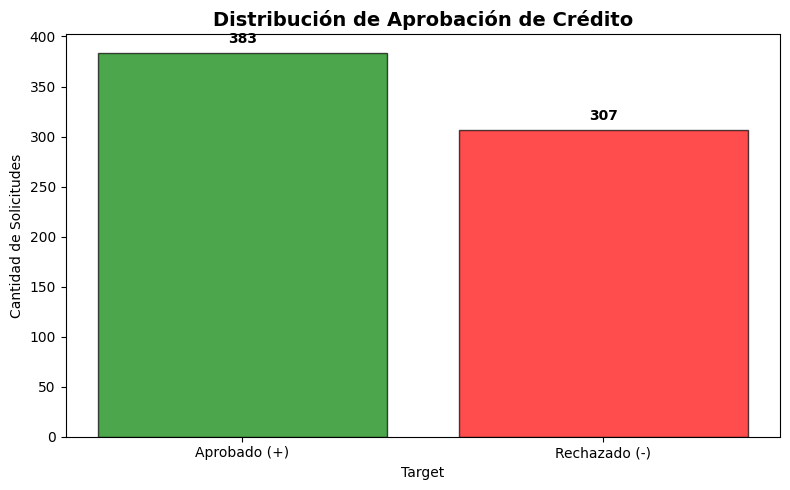


Balance del dataset:
Aprobados (+): 383 (55.5%)
Rechazados (-): 307 (44.5%)


In [7]:
# Distribución del target
target_counts = df['target'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(['Aprobado (+)', 'Rechazado (-)'], target_counts.values, color=['green', 'red'], alpha=0.7, edgecolor='black')
plt.title('Distribución de Aprobación de Crédito', fontsize=14, fontweight='bold')
plt.ylabel('Cantidad de Solicitudes')
plt.xlabel('Target')

# Agregar valores sobre las barras
for i, v in enumerate(target_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nBalance del dataset:")
print(f"Aprobados (+): {target_counts.iloc[0]} ({target_counts.iloc[0]/len(df)*100:.1f}%)")
print(f"Rechazados (-): {target_counts.iloc[1]} ({target_counts.iloc[1]/len(df)*100:.1f}%)")

---
# LIMPIEZA DE DATOS

## Tratamiento de Valores Faltantes

In [8]:
# Eliminar filas con valores faltantes
print(f"Filas antes de eliminar NaN: {len(df)}")
df_clean = df.dropna()
print(f"Filas después de eliminar NaN: {len(df_clean)}")
print(f"Filas eliminadas: {len(df) - len(df_clean)} ({(len(df) - len(df_clean))/len(df)*100:.1f}%)")

Filas antes de eliminar NaN: 690
Filas después de eliminar NaN: 653
Filas eliminadas: 37 (5.4%)


## Tratamiento de Outliers

In [9]:
# Estadísticas de variables numéricas
numeric_cols = df_clean.select_dtypes(include=['number']).columns.tolist()
df_clean[numeric_cols].describe()

,A2,A3,A8,A11,A14,A15
count,653.000000,653.000000,653.000000,653.000000,653.000000,653.000000
mean,31.503813,4.829533,2.244296,2.502297,180.359877,1013.761103
std,11.838267,5.027077,3.371120,4.968497,168.296811,5253.278504
min,13.750000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,22.580000,1.040000,0.165000,0.000000,73.000000,0.000000
50%,28.420000,2.835000,1.000000,0.000000,160.000000,5.000000
75%,38.250000,7.500000,2.625000,3.000000,272.000000,400.000000
max,76.750000,28.000000,28.500000,67.000000,2000.000000,100000.000000


In [10]:
print("✅ No se detectan outliers problemáticos")

✅ No se detectan outliers problemáticos


---
# PREPROCESAMIENTO

## Encoding de Variables Categóricas

In [11]:
# Identificar variables categóricas (excepto el target)
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('target')

print(f"Variables categóricas: {categorical_cols}")

# One-Hot Encoding manual
df_encoded = df_clean.copy()

for col in categorical_cols:
    dummies = pd.get_dummies(df_encoded[col], prefix=col, drop_first=True)
    df_encoded = pd.concat([df_encoded, dummies], axis=1)
    df_encoded.drop(col, axis=1, inplace=True)

print(f"\n✅ Encoding completado")
print(f"Shape después de encoding: {df_encoded.shape}")

Variables categóricas: ['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13']

✅ Encoding completado
Shape después de encoding: (653, 38)


## Codificar Target

In [12]:
# Convertir target a binario (0 = rechazado, 1 = aprobado)
df_encoded['target'] = (df_encoded['target'] == '+').astype(int)

print("✅ Target codificado")
print(f"\nDistribución:")
print(df_encoded['target'].value_counts())

✅ Target codificado

Distribución:
target
0    357
1    296
Name: count, dtype: int64


## Separar Features y Target

In [13]:
# Target
y = df_encoded['target'].values

# Features
X = df_encoded.drop('target', axis=1).values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (653, 37)
y shape: (653,)


## Train-Test Split Manual (80-20)

In [14]:
# Configuración
np.random.seed(42)
test_size = 0.2

# Generar índices aleatorios
n_samples = len(X)
indices = np.random.permutation(n_samples)

# Calcular punto de corte
test_size_abs = int(n_samples * test_size)
train_size_abs = n_samples - test_size_abs

# Dividir índices
train_indices = indices[:train_size_abs]
test_indices = indices[train_size_abs:]

# Crear conjuntos
X_train = X[train_indices]
X_test = X[test_indices]
y_train = y[train_indices]
y_test = y[test_indices]

print(f"✅ Split completado")
print(f"Train: {X_train.shape[0]} muestras")
print(f"Test: {X_test.shape[0]} muestras")
print(f"\nDistribución target en Train: {np.bincount(y_train)}")
print(f"Distribución target en Test: {np.bincount(y_test)}")

✅ Split completado
Train: 523 muestras
Test: 130 muestras

Distribución target en Train: [293 230]
Distribución target en Test: [64 66]


## Escalado Manual (StandardScaler)

Fórmula: `x_scaled = (x - mean) / std`

**IMPORTANTE**: Calcular media y desviación estándar SOLO con datos de entrenamiento para evitar data leakage.

In [15]:
# CONVERTIR A FLOAT ANTES DEL ESCALADO (prevenir errores de tipo)
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Calcular media y desviación estándar del TRAIN set
mean_train = X_train.mean(axis=0)
std_train = X_train.std(axis=0)

# Evitar división por cero (columnas constantes)
std_train[std_train == 0] = 1

# Aplicar escalado
X_train_scaled = (X_train - mean_train) / std_train
X_test_scaled = (X_test - mean_train) / std_train

# Convertir a float explícitamente
X_train_scaled = X_train_scaled.astype(float)
X_test_scaled = X_test_scaled.astype(float)

print("✅ Escalado completado")
print(f"\nMedia de X_train_scaled (primeras 5 features): {X_train_scaled.mean(axis=0)[:5]}")
print(f"Desv. Std de X_train_scaled (primeras 5 features): {X_train_scaled.std(axis=0)[:5]}")

✅ Escalado completado

Media de X_train_scaled (primeras 5 features): [ 4.81875003e-17  3.54719441e-16  1.65578195e-17  8.51241745e-17
 -9.34030843e-18]
Desv. Std de X_train_scaled (primeras 5 features): [1. 1. 1. 1. 1.]


---
# VALIDACIÓN FINAL

## 1. Verificar Data Leakage

In [16]:
shared_indices = np.intersect1d(train_indices, test_indices)

if len(shared_indices) == 0:
    print("✅ No hay data leakage (índices únicos en train y test)")
else:
    print(f"⚠️ ALERTA: {len(shared_indices)} índices compartidos detectados")

✅ No hay data leakage (índices únicos en train y test)


## 2. Verificar NaN e Infinitos

In [17]:
nan_train = np.isnan(X_train_scaled).sum()
nan_test = np.isnan(X_test_scaled).sum()
inf_train = np.isinf(X_train_scaled).sum()
inf_test = np.isinf(X_test_scaled).sum()

print(f"NaN en X_train_scaled: {nan_train}")
print(f"NaN en X_test_scaled: {nan_test}")
print(f"Infinitos en X_train_scaled: {inf_train}")
print(f"Infinitos en X_test_scaled: {inf_test}")

if nan_train == 0 and nan_test == 0 and inf_train == 0 and inf_test == 0:
    print("\n✅ Datos limpios (sin NaN ni infinitos)")
else:
    print("\n⚠️ ALERTA: Hay NaN o infinitos en los datos")

NaN en X_train_scaled: 0
NaN en X_test_scaled: 0
Infinitos en X_train_scaled: 0
Infinitos en X_test_scaled: 0

✅ Datos limpios (sin NaN ni infinitos)


## 3. Comparar Distribuciones Train vs Test

In [18]:
print("=== COMPARACIÓN TRAIN vs TEST (primeras 5 features) ===")
print("\nMEDIA:")
print(f"Train: {X_train_scaled.mean(axis=0)[:5]}")
print(f"Test:  {X_test_scaled.mean(axis=0)[:5]}")

print("\nDESVIACIÓN ESTÁNDAR:")
print(f"Train: {X_train_scaled.std(axis=0)[:5]}")
print(f"Test:  {X_test_scaled.std(axis=0)[:5]}")

print("\n✅ Las distribuciones deberían ser similares (train estandarizado, test escalado con stats de train)")

=== COMPARACIÓN TRAIN vs TEST (primeras 5 features) ===

MEDIA:
Train: [ 4.81875003e-17  3.54719441e-16  1.65578195e-17  8.51241745e-17
 -9.34030843e-18]
Test:  [0.17642556 0.03098403 0.21461585 0.0368255  0.00196873]

DESVIACIÓN ESTÁNDAR:
Train: [1. 1. 1. 1. 1.]
Test:  [1.07493421 0.92376324 1.29510681 0.81565306 1.03698158]

✅ Las distribuciones deberían ser similares (train estandarizado, test escalado con stats de train)


## Resumen Final

In [19]:
print("="*60)
print("RESUMEN DEL PREPROCESAMIENTO")
print("="*60)
print(f"Dataset original: {df.shape}")
print(f"Dataset después de limpieza: {df_clean.shape}")
print(f"Features después de encoding: {X.shape[1]}")
print(f"Train set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")
print(f"\nTarget (aprobación de crédito):")
print(f"  - Clase 0 (rechazado): {(y==0).sum()} casos")
print(f"  - Clase 1 (aprobado): {(y==1).sum()} casos")
print(f"\n✅ Datos listos para entrenamiento de modelos de clasificación")
print("="*60)

RESUMEN DEL PREPROCESAMIENTO
Dataset original: (690, 16)
Dataset después de limpieza: (653, 16)
Features después de encoding: 37
Train set: (523, 37)
Test set: (130, 37)

Target (aprobación de crédito):
  - Clase 0 (rechazado): 357 casos
  - Clase 1 (aprobado): 296 casos

✅ Datos listos para entrenamiento de modelos de clasificación
